In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"voltnorakon","key":"71a4dd9e82346e6801bf28b6165df864"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import os

dataset_id = 'parvezkabir221155539/mushroom-species-classification-dataset'

# Create a directory for the dataset if it doesn't exist
dataset_dir = './mushroom_dataset'
os.makedirs(dataset_dir, exist_ok=True)

# Download the dataset files into the created directory
!kaggle datasets download -d {dataset_id} -p {dataset_dir}

Dataset URL: https://www.kaggle.com/datasets/parvezkabir221155539/mushroom-species-classification-dataset
License(s): apache-2.0
100% 4.97G/4.97G [00:59<00:00, 89.5MB/s]



In [ ]:
import zipfile

# Get the path to the downloaded zip file (assuming it's named after the dataset ID)
zip_file_path = os.path.join(dataset_dir, dataset_id.split('/')[-1] + '.zip')

# Check if the zip file exists before attempting to extract
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print(f'Dataset extracted to: {dataset_dir}')
    # Optionally, remove the zip file after extraction
    # os.remove(zip_file_path)
else:
    print(f'Error: Zip file not found at {zip_file_path}')

# List the contents of the extracted directory to verify
print('\nContents of the dataset directory:')
!ls -l {dataset_dir}

Dataset extracted to: ./mushroom_dataset

Contents of the dataset directory:
total 5208784
drwxr-xr-x 10 root root       4096 Jun 16 08:53 'Mashroom Dataset'
-rw-r--r--  1 root root 5333785147 May 24 19:38  mushroom-species-classification-dataset.zip


In [ ]:
import os

data_path = os.path.join(dataset_dir, 'Mashroom Dataset')
print(f"Contents of '{data_path}':")
!ls -l "{data_path}"

Contents of './mushroom_dataset/Mashroom Dataset':
total 60
drwxr-xr-x 2 root root  4096 Jun 16 08:52 'Ear Mushroom'
drwxr-xr-x 2 root root  4096 Jun 16 08:52 'Golden Oyster  Mushroom'
drwxr-xr-x 2 root root  4096 Jun 16 08:52 'Gray Oyster Mushroom'
drwxr-xr-x 2 root root  4096 Jun 16 08:52 'Lions Mane Mushroom'
drwxr-xr-x 2 root root  4096 Jun 16 08:52  MilkyMushroom
drwxr-xr-x 2 root root 20480 Jun 16 08:52 'Oyster (Po10) Mushroom'
drwxr-xr-x 2 root root 16384 Jun 16 08:53 'Pink Oyster Mashroom'
drwxr-xr-x 2 root root  4096 Jun 16 08:53 'Reishi Mushroom'


In [ ]:
import pandas as pd

image_dir = os.path.join(dataset_dir, 'Mashroom Dataset')

# Create lists to store image paths and labels
image_paths = []
labels = []

# Iterate through each subdirectory (which represents a class/label)
for class_name in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            image_paths.append(image_path)
            labels.append(class_name)

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

# Display the first few rows and the shape of the DataFrame
print("DataFrame head:")
display(df.head())

print("\nDataFrame shape:")
print(df.shape)

DataFrame head:


,image_path,label
0,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom
1,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom
2,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom
3,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom
4,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom



DataFrame shape:
(743, 2)


Number of unique mushroom species (classes): 8

Class distribution:


,count
label,
Oyster (Po10) Mushroom,230
Pink Oyster Mashroom,225
Reishi Mushroom,73
Ear Mushroom,72
Golden Oyster Mushroom,57


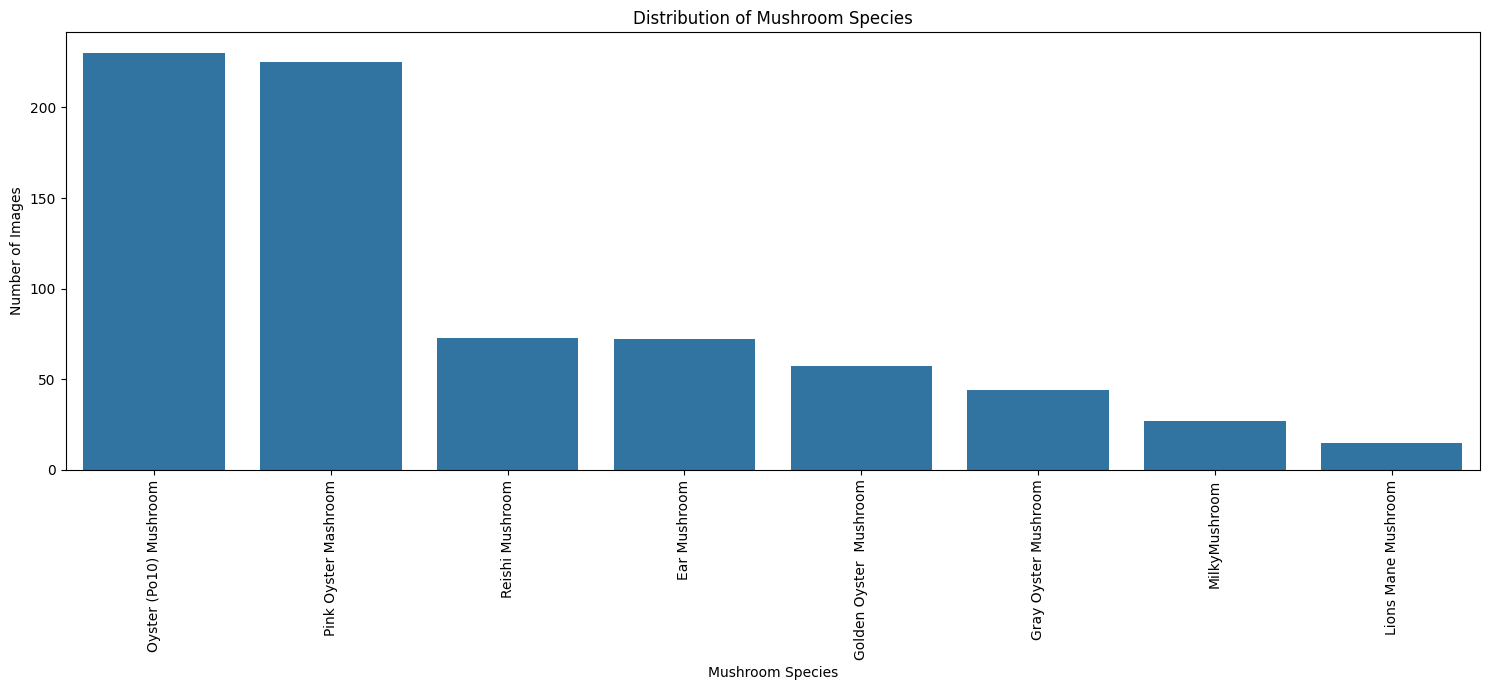

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the number of unique classes
num_classes = df['label'].nunique()
print(f"Number of unique mushroom species (classes): {num_classes}")

# Get the distribution of classes
class_distribution = df['label'].value_counts()
print("\nClass distribution:")
display(class_distribution.head())

# Visualize the class distribution
plt.figure(figsize=(15, 7))
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title('Distribution of Mushroom Species')
plt.xlabel('Mushroom Species')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
print("Missing values in DataFrame:")
display(df.isnull().sum())

Missing values in DataFrame:


,0
image_path,0
label,0


In [ ]:
print(f"Initial DataFrame shape: {df.shape}")
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"DataFrame shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Initial DataFrame shape: (743, 2)
Number of duplicate rows found: 0
No duplicate rows found.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'label' column
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Display the mapping of original labels to encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping (original -> encoded):")
print(label_mapping)

# Display the first few rows with the new encoded label
print("\nDataFrame head with encoded labels:")
display(df.head())

Label mapping (original -> encoded):
{'Ear Mushroom': np.int64(0), 'Golden Oyster  Mushroom': np.int64(1), 'Gray Oyster Mushroom': np.int64(2), 'Lions Mane Mushroom': np.int64(3), 'MilkyMushroom': np.int64(4), 'Oyster (Po10) Mushroom': np.int64(5), 'Pink Oyster Mashroom': np.int64(6), 'Reishi Mushroom': np.int64(7)}

DataFrame head with encoded labels:


,image_path,label,label_encoded
0,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom,3
1,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom,3
2,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom,3
3,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom,3
4,./mushroom_dataset/Mashroom Dataset/Lions Mane...,Lions Mane Mushroom,3


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['image_path']]
y = df['label_encoded']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of labels in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of labels in validation set:")
display(y_val.value_counts(normalize=True))
print("\nDistribution of labels in test set:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (445, 1)
Shape of X_val: (149, 1)
Shape of X_test: (149, 1)
Shape of y_train: (445,)
Shape of y_val: (149,)
Shape of y_test: (149,)

Distribution of labels in training set:


,proportion
label_encoded,
5,0.310112
6,0.303371
0,0.096629
7,0.096629
1,0.076404
2,0.058427
4,0.038202
3,0.020225



Distribution of labels in validation set:


,proportion
label_encoded,
5,0.308725
6,0.302013
7,0.100671
0,0.093960
1,0.080537
2,0.060403
4,0.033557
3,0.020134



Distribution of labels in test set:


,proportion
label_encoded,
5,0.308725
6,0.302013
0,0.100671
7,0.100671
1,0.073826
2,0.060403
4,0.033557
3,0.020134


## Step 8: Image Preprocessing and Data Augmentation

For image classification tasks, images need to be transformed into a consistent format suitable for deep learning models. This typically involves resizing, converting to tensors, and normalizing pixel values. Data augmentation can also be applied to increase the diversity of the training data and improve model generalization.

In [ ]:
import torchvision.transforms as transforms

# Define image transformations
# For training, include data augmentation (random flips, rotations, etc.)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 (common for many pre-trained models)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

# For validation/testing, only resize and normalize
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Image transformations defined.")

Image transformations defined.


## Step 9: Create Custom Dataset and DataLoaders

We need a custom PyTorch `Dataset` class to load images from the file paths and apply the defined transformations. Then, `DataLoader`s will be used to efficiently load batches of data for training and testing.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class MushroomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label_encoded']

        if self.transform:
            image = self.transform(image)

        return image, label

# Create datasets
train_dataset = MushroomDataset(X_train.join(y_train), transform=train_transforms)
val_dataset = MushroomDataset(X_val.join(y_val), transform=test_transforms)
test_dataset = MushroomDataset(X_test.join(y_test), transform=test_transforms)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

# Example of getting a batch
for images, labels in train_loader:
    print(f"Shape of image batch: {images.shape}") # Expected: [batch_size, 3, 224, 224]
    print(f"Shape of label batch: {labels.shape}") # Expected: [batch_size]
    break

Training dataset size: 445
Validation dataset size: 149
Test dataset size: 149
Number of batches in train_loader: 14
Number of batches in val_loader: 5
Number of batches in test_loader: 5
Shape of image batch: torch.Size([32, 3, 224, 224])
Shape of label batch: torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model
class MushroomCNN(nn.Module):
    def __init__(self, num_classes):
        super(MushroomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

num_classes = df['label'].nunique()
model = MushroomCNN(num_classes)

# Move the model to the appropriate device (CPU or GPU)
model = model.to(device)
print(f"Number of output classes: {num_classes}")

Using device: cuda
Number of output classes: 8


## Step 11: Define Loss Function, Optimizer, and Training Loop

To train our model, we need to define a loss function (e.g., Cross-Entropy Loss for classification), an optimizer (e.g., Adam or SGD), and then implement a training loop that iterates through the data, computes predictions, calculates the loss, and updates the model's weights.

In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Only optimize the newly added FC layer

# Training function
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        print(f"Epoch {epoch+1}/{num_epochs}")
        for inputs, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct_predictions / total_samples
        print(f'Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_accuracy:.4f}')

        model.eval()
        running_val_loss = 0.0
        correct_val_predictions = 0
        total_val_samples = 0
        for inputs, labels in tqdm(val_loader, desc=f"Validation for epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            output_val = model(inputs)
            loss = criterion(output_val, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(output_val.data, 1)
            total_val_samples += labels.size(0)
            correct_val_predictions += (predicted == labels).sum().item()
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_accuracy = correct_val_predictions / total_val_samples
        print(f'Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_accuracy:.4f}')

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f'Accuracy on the test set: {accuracy:.4f}')
    return accuracy

print("Loss function, optimizer, and training/evaluation functions defined.")

Loss function, optimizer, and training/evaluation functions defined.


In [ ]:
# Train the model
num_epochs = 10
print(f"Starting training for {num_epochs} epochs...")
train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=num_epochs)

print("Training finished. Evaluating model performance...")

# Evaluate the model
final_accuracy = evaluate_model(model, test_loader)
print(f"Final Test Accuracy: {final_accuracy:.4f}")

Starting training for 10 epochs...
Epoch 1/10


Training Epoch 1: 100%|██████████| 14/14 [03:39<00:00, 15.65s/it]


Training Loss: 2.0788, Training Accuracy: 0.1258


Validation for epoch 1: 100%|██████████| 5/5 [01:12<00:00, 14.59s/it]


Validation Loss: 2.0790, Validation Accuracy: 0.0201
Epoch 2/10


...

Training Loss: 2.0786, Training Accuracy: 0.1326


Validation for epoch 2: 100%|██████████| 5/5 [01:12<00:00, 14.51s/it]


Validation Loss: 2.0790, Validation Accuracy: 0.0201
Epoch 3/10


Training Epoch 3:  21%|██▏       | 3/14 [00:52<03:12, 17.45s/it]


KeyboardInterrupt: 